Kai Rothe, Karim Zaghw

## 1)

Let's assume we have a neuron with cyclic behaviour. It starts with birth (second 1) and then for each second if it is devisible with 3 without a residual the probability of emiting a single spike during this second is 0.8 (otherwise the neuron is silent). If the second's number is not devisible with 3 then the probability of our neuron to fire is 0.1 (and it is still silent in between).

See the Figure below for a plot of the probability of the neuron to fire.

All results must be computed in bits!

**(a)** Compute analytically the active information storage with a single past time step.*(3 points)*

*Hint: Take the series as a discrete, binary sequence and follow the definition.*

We want to calculate
$$
I(X_{t-1}:X_t) = H(X_t) - H(X_t \mid X_{t-1}) = \sum_{x_{t-1} \in \{0,  1\}}  \sum_{x_t \in \{0,  1\}} p(X_t = x_t, X_{t-1} = x_{t-1}) \log_2 \left( \frac{p(X_t = x_t \mid X_{t-1} = x_{t-1})}{p(X_t = x_t)} \right)
$$

We can manually calculate the joint probabilities:

| $X_{t-1}$ | $X_t$ | $p(X_t , X_{t-1}\mid t \bmod 3 = 0)$ | $p(X_t , X_{t-1} \mid t \bmod 3 = 1)$ | $p(X_t , X_{t-1} \mid t \bmod 3 = 2)$ | $p(X_t , X_{t-1})$                              | $p(X_t \mid X_{t-1})$                               |
| --------- | ----- | ------------------------------------ | ------------------------------------- | ------------------------------------- | ----------------------------------------------- | --------------------------------------------------- |
| 0         | 0     | $0.9 \cdot 0.2 = 0.18$               | $0.2 \cdot 0.9 = 0.18$                | $0.9 \cdot 0.9 = 0.81$                | $\frac{0.18 + 0.18 + 0.81}{3} = 0.39$           | $0.39 \cdot \frac{3}{2} = \frac{117}{200}$          |
| 0         | 1     | $0.9 \cdot 0.8 = 0.72$               | $0.2 \cdot 0.1 = 0.02$                | $0.9 \cdot 0.1 = 0.09$                | $\frac{0.72 + 0.02 + 0.09}{3} = \frac{83}{300}$ | $\frac{83}{300} \cdot \frac{3}{2} = \frac{83}{200}$ |
| 1         | 0     | $0.1 \cdot 0.2 = 0.02$               | $0.8 \cdot 0.9 = 0.72$                | $0.1 \cdot 0.9 = 0.09$                | $\frac{0.02 + 0.72 + 0.09}{3} = \frac{83}{300}$ | $\frac{83}{300} \cdot 3 = 0.83$                     |
| 1         | 1     | $0.1 \cdot 0.8 = 0.08$               | $0.8 \cdot 0.1 = 0.08$                | $0.1 \cdot 0.1 = 0.01$                | $\frac{0.08 + 0.08 + 0.01}{3} = \frac{17}{300}$ | $\frac{17}{300} \cdot 3 = 0.17$                     |

We also have

- $P(X_t=0) = \frac{117 + 83}{300} = \frac{200}{300} = \frac{2}{3}$
- $P(X_t=1) = \frac{83 + 17}{300} = \frac{100}{300} = \frac{1}{3}$

So we compute each term in the sum:

$$
I(X_{t-1};X_t) =
\frac{117}{300}\log_2\left(\frac{\frac{117}{200}}{\frac{2}{3}}\right)
+ \frac{83}{300}\log_2\left(\frac{\frac{83}{200}}{\frac{1}{3}}\right)
+ \frac{83}{300}\log_2\left(\frac{0.83}{\frac{2}{3}}\right)
+ \frac{17}{300}\log_2\left(\frac{0.17}{\frac{1}{3}}\right)
= 0.04636 \text{ bits}
$$

**(b)** Simulate 1000 spikes and compute for a single past time step the active information storage numerically. *(3 points)*

*Hint: First code and test for yourself the framework of the tuning function and generating the time series.

*Hint: Use sklearn.metrics.mutual_info_score. Check units!*

In [1]:
import numpy as np
from sklearn.metrics import mutual_info_score
import matplotlib.pyplot as plt

In [7]:
n_spikes = 10000000
seed = 42
np.random.seed(seed)

t = np.arange(1, n_spikes + 1)
p = np.where(t % 3 == 0, 0.8, 0.1)
X = (np.random.rand(n_spikes) < p).astype(int)

X_prev = X[:-1]
X_curr = X[1:]

mi_nats = mutual_info_score(X_prev, X_curr)
mi_bits = mi_nats / np.log(2)

print(f"One-step active information storage (bits): {mi_bits:.4f}")

One-step active information storage (bits): 0.0463


**(c)** What would happen with active information storage if the probability to fire is always 0.1 (analysis and numerics)? *(2 point)*

If the firing probability is always $0.1$, then $X_t$ and $X_{t-1}$ can be considered independent Bernoulli RVs and $p(X_t \mid X_{t-1}) = p(X_t)$ so
$$
I(X_{t-1}:X_t) = \sum_{x_{t-1} \in \{0,  1\}}  \sum_{x_t \in \{0,  1\}} p(X_t = x_t, X_{t-1} = x_{t-1}) \log_2(1) = 0
$$

In [8]:
n_spikes = 10000000
seed = 42
np.random.seed(seed)

t = np.arange(1, n_spikes + 1)
p = np.ones_like(t) * 0.1
X = (np.random.rand(n_spikes) < p).astype(int)

X_prev = X[:-1]
X_curr = X[1:]

mi_nats = mutual_info_score(X_prev, X_curr)
mi_bits = mi_nats / np.log(2)

print(f"One-step active information storage (bits): {mi_bits:.4f}")

One-step active information storage (bits): 0.0000


**(d)** What would happen, if the probabilities are 0 and 1 (instead of 0.1 and 0.8) (analysis) *(1 point)*?


Calculating the joint probabilities again we find

| $X_{t-1}$ | $X_t$ | $p(X_t , X_{t-1}\mid t \bmod 3 = 0)$ | $p(X_t , X_{t-1} \mid t \bmod 3 = 1)$ | $p(X_t , X_{t-1} \mid t \bmod 3 = 2)$ | $p(X_t , X_{t-1})$ | $p(X_t \mid X_{t-1})$                         |
| --------- | ----- | ------------------------------------ | ------------------------------------- | ------------------------------------- | ------------------ | --------------------------------------------- |
| 0         | 0     | $0$                                  | $0$                                   | $1$                                   | $\frac{1}{3}$      | $\frac{1}{3} \cdot \frac{3}{2} = \frac{1}{2}$ |
| 0         | 1     | $1$                                  | $0$                                   | $0$                                   | $\frac{1}{3}$      | $\frac{1}{3} \cdot \frac{3}{2} = \frac{1}{2}$ |
| 1         | 0     | $0$                                  | $1$                                   | $0$                                   | $\frac{1}{3}$      | $\frac{1}{3} \cdot 3 = 1$                     |
| 1         | 1     | $0$                                  | $0$                                   | $0$                                   | $0$                | $0$                                           |

We also have
- $P(X_t=0) = \frac{2}{3}$
- $P(X_t=1) = \frac{1}{3}$

So we compute each term in the sum:

$$
I(X_{t-1};X_t) =
\frac{1}{3}\log_2\left(\frac{\frac{1}{2}}{\frac{2}{3}}\right)
+ \frac{1}{3}\log_2\left(\frac{\frac{1}{2}}{\frac{1}{3}}\right)
+ \frac{1}{3}\log_2\left(\frac{1}{\frac{2}{3}}\right)
= 0.2516  \text{ bits}
$$

In [9]:
n_spikes =  10000000
seed = 42
np.random.seed(seed)

t = np.arange(1, n_spikes + 1)
p = np.where(t % 3 == 0, 1, 0)
X = (np.random.rand(n_spikes) < p).astype(int)

X_prev = X[:-1]
X_curr = X[1:]

mi_nats = mutual_info_score(X_prev, X_curr)
mi_bits = mi_nats / np.log(2)

print(f"One-step active information storage (bits): {mi_bits:.4f}")

One-step active information storage (bits): 0.2516


**(e)** Compute analytically the active information storage for two past time steps (original probabilities).
*(2 points)*

In [46]:
n_past_ts = 2
joint = np.zeros([2] * (n_past_ts + 1))

# Build an array of time indices for each phase 0,1,2
t = np.vstack([np.arange(1, n_past_ts + 2) + i for i in range(3)])
p = np.where(t % 3 == 0, 0.8, 0.1)

# Fill the joint dist
for idx in np.ndindex(*([2] * (n_past_ts + 1))):
    probs = []
    for phi in range(3):
        prob_phi = 1.0
        for lag, x in enumerate(idx):
            pj = p[phi, lag]
            prob_phi *= pj if x == 1 else (1 - pj)
        probs.append(prob_phi)
    joint[idx] = np.mean(probs)

# Compute the marginal p(X_t)
p_t = joint.sum(axis=tuple(range(n_past_ts)))

# Shannon entropy H(X_t)
H_t = -np.nansum(p_t * np.log2(p_t))

# Compute conditional distribution p(X_t | past)
# Marginal over the past (axes 0 and 1)
p_past = joint.sum(axis=-1)  # shape (2,2)

# Conditional p(X_t | X_{t-2}, X_{t-1})
cond = joint / p_past[..., None]

# Conditional entropy H(X_t | X_{t-2},X_{t-1})
H_cond = -np.nansum(joint * np.log2(cond))

# Active Information Storage with 2 past steps
AIS2 = H_t - H_cond

print(f"H(X_t)            = {H_t:.6f} bits")
print(f"H(X_t | past 2)   = {H_cond:.6f} bits")
print(f"AIS (k=2)         = {AIS2:.6f} bits")

H(X_t)            = 0.918296 bits
H(X_t | past 2)   = 0.786490 bits
AIS (k=2)         = 0.131806 bits


**(f)** How does the number of past time steps and the length of the time series influence active information storage?
To determine this scale up your numerical computation of active information storage to handle longer timeseries and include more time steps (I managed to scale up to 100,000 time steps for timeseries and 60 past time steps for active information storage).
Compute and plot (for various time series lengths) how active information storage depends on the number of time steps considered.
Briefly (!), explain and discuss what you conclude based on your results. In particular, also consider how much information is available in the time series and how the cyclic behaviour incluences active information storage.
*(5 points)*

*Hint: compress the information of the past time steps by mapping it to integers.*

In [10]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

def simulate_spikes(N, seed=None):
    t = np.arange(1, N + 1)
    p = np.where(t % 3 == 0, 0.8, 0.1)
    if seed is not None:
        np.random.seed(seed)
    return (np.random.rand(N) < p).astype(np.uint8)

def compute_ais_one_step(X, k):
    N = len(X)
    M = N - k
    powers = (1 << np.arange(k, dtype=np.uint64))  
    past_int = np.empty(M, dtype=np.uint64)
    for i in range(M):
        past_int[i] = np.dot(X[i : i+k].astype(np.uint64), powers)
    curr = X[k:]         
    mi_nats = mutual_info_score(past_int, curr)
    return mi_nats / np.log(2)
    
# Parameters
lengths = [1000, 10000, 100000, 1000000]
k_max = 60

# Preallocate results
ais_results = np.zeros((len(lengths), k_max))

# Run simulations and compute AIS for each history length k
for idx, L in enumerate(lengths):
    print(f"Length = {L}")
    X = simulate_spikes(L, seed=42)
    for k in range(1, k_max + 1):
        ais_results[idx, k-1] = compute_ais_one_step(X, k)

Length = 1000
Length = 10000
Length = 100000
Length = 1000000


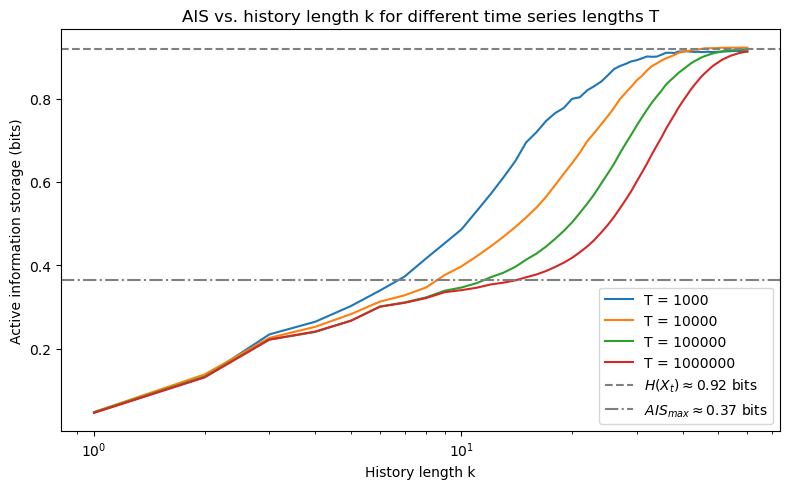

In [50]:
# Plotting
plt.figure(figsize=(8, 5))
for idx, L in enumerate(lengths):
    plt.plot(range(1, k_max + 1), ais_results[idx], label=f"T = {L}")
plt.axhline(0.918, color='gray', linestyle='--', label=r'$H(X_t) \approx 0.92$ bits', linewidth=1.5)
plt.axhline(0.365, color='gray', linestyle='-.', label=r"$AIS_{max} \approx 0.37$ bits", linewidth=1.5)
plt.xlabel("History length k")
plt.ylabel("Active information storage (bits)")
plt.xscale("log")
plt.title("AIS vs. history length k for different time series lengths T")
plt.legend()
plt.tight_layout()
plt.show()

When we plot the Active Information Storage as a function of history length $k$, we observe that the 1. **AIS continues to rise past $k=2$.** This is because two previous steps only determine $t \text{ mod } 3$ up to the intrinsic noise of spiking at each time step in the cycle. More repetitions of the cycle allow better inference (more samples) of $t \text{ mod } 3$, and thus should reach the theoretical maximum 
  $$ AIS_{max} = I(X_t ; t \text{ mod } 3) = H(X_t) - H(X_t\mid\ t \text{ mod } 3) 
    = H(X_t) - [\frac13 H(X_t \sim Ber(0.8)) + \frac23 H(X_t \sim Ber(0.1))]
    \approx 0.37 \text{ bits}
  $$
for infinite k. 

In [51]:
H_given_t_mod_3 = 1 / 3 * (-0.8 * np.log2(0.8) -0.2 * np.log2(0.2)) + 2 / 3 * (-0.1 * np.log2(0.1) -0.9 * np.log2(0.9))
AIS_max = H_t - H_given_t_mod_3
print(f"AIS_max = {AIS_max:.5f} bits")

AIS_max = 0.36499 bits


But we observe 2. that the AIS **plateaus only at $\approx 0.918$ bits**, well above the theoretical maximum. The reason the empirical estimator overshoots is due to undersampling because of the finite time steps $T$ of the sampled time series: The mutual information is computed as
   $$
     \widehat I
     = \sum_{x_{\mathrm{past}},x}
       \hat p(x_{\mathrm{past}},x)\,
       \log\frac{\hat p(x\mid x_{\mathrm{past}})}{\hat p(x)}.
   $$

   Encoding $k$ past bits into one integer gives up to $2^k$ intergers encoding the past state. For large $k$ compared to timeseries steps $T$, i.e. $2^k \geq T$, each observed past‑state has only one or zero samples, and the empirical conditional
   $\hat p(x\mid x_{\mathrm{past}})$ becomes essentially 1 for the one $x$ that actually follows that past.  Thus for every bin where $\hat p(x_{\mathrm{past}},x)>0$,

   $$
     \log\frac{\hat p(x\mid x_{\mathrm{past}})}{\hat p(x)}
     \;\approx\;
     \log\frac{1}{\hat p(x)}
     \;=\;
     -\log\hat p(x).
   $$

   Then the mutual information becomes

   $$
     \widehat I
     \;\approx\;
     \sum_{x_{\mathrm{past}},x}
       \hat p(x_{\mathrm{past}},x)\,\bigl[-\log\hat p(x)\bigr]
     =
     \sum_{x}\hat p(x)\bigl[-\log\hat p(x)\bigr]
     \approx H(X_t) ≈ 0.918 bits,
   $$

   the marginal entropy of $X_t$.  That is why the AIS curve asymptotes to ≈ 0.918 bits.

This explains the sequential divergence of the AIS estimates because AIS estimators with higher $T$ remain longer (i.e. for higher $k$) below and converge closer to the theoretical maximum than AIS estimates with smaller $T$. 

To obtain the correct AIS curve we could:
* **Limit $k$.**  Keep $k$ small enough that $2^k\ll N$.  Here, $k=2$ already captures the full period‑3 memory; going beyond $k=2$ only invites bias.
* **Compress the past.**  Map the past $k$ spikes to the 3‑state phase $t\bmod3$.  That yields 3 bins and recovers the theoretical AIS ≈ 0.13 bits.
* **Bias corrections or alternative estimators.**  Use Miller–Madow or Panzeri–Treves corrections, k‑nearest‑neighbour MI estimators, or baseline subtraction with surrogates to mitigate finite‑sample artefacts.

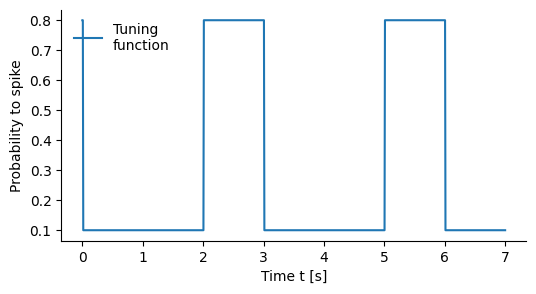

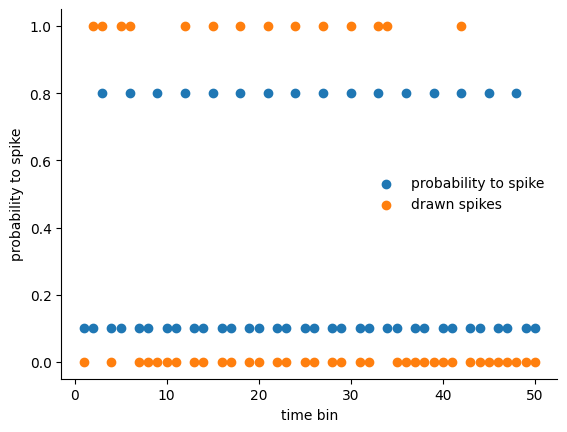